In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

# Nonlinear regression:

In [8]:
x = np.linspace(0, 12, 500)
y = np.sin(0.5*x) + np.random.normal(0, 0.3, x.shape)

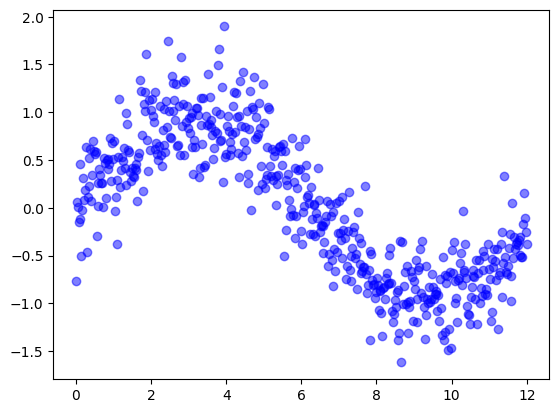

In [11]:
plt.scatter(x, y, c='blue', alpha=0.5);

In [12]:
def gausian_1d(x, center=0, eps=1):
    return np.exp(-eps*(x-center)**2)

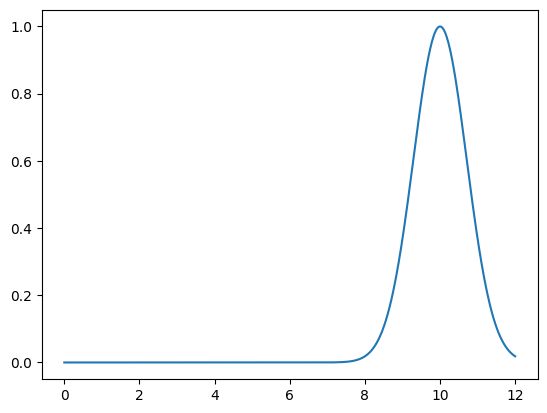

In [17]:
plt.plot(x, gausian_1d(x, center=10, eps=1));

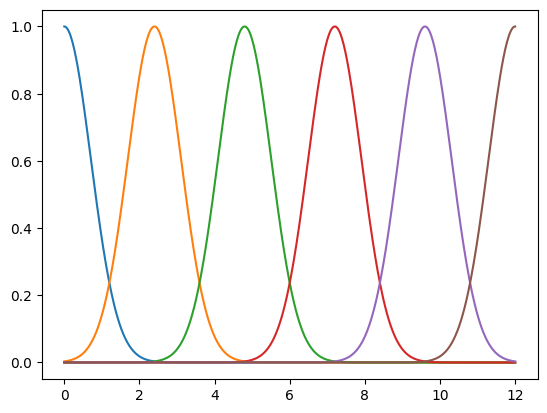

In [101]:
m = 6
eps = 0.05
centers = np.linspace(0, 12, m)

for c in centers:
    plt.plot(x, gausian_1d(x, center=c, eps=1))

In [102]:
phi = np.zeros((y.shape[0], m))
for i in range(phi.shape[0]):
    for j in range(phi.shape[1]):
        phi[i, j] = gausian_1d(x[i], center=centers[j], eps=eps)

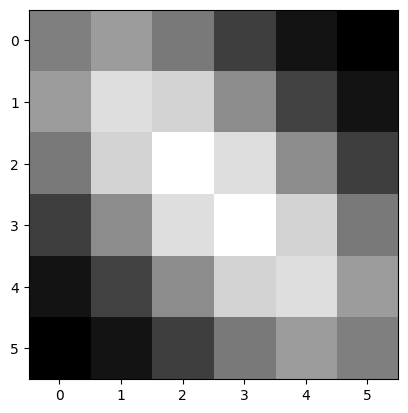

In [103]:
plt.imshow(phi.T@phi, cmap='gray');

In [104]:
l = np.linalg.inv(phi.T@phi)@phi.T@y

In [105]:
l.shape

(6,)

In [106]:
l

array([-1.90394857,  2.97529031, -1.25089768,  1.50949105, -3.06718115,
        1.58081188])

In [107]:
y_pred_kernel = 0
for j in range(m):
    y_pred_kernel += l[j] * gausian_1d(x, center=centers[j], eps=eps)

In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [109]:
linear = LinearRegression()
linear.fit(x.reshape(-1, 1), y)

LinearRegression()

In [132]:
steps = [('poly_features', PolynomialFeatures(degree=5)),
         ('Linear_Regression', LinearRegression(fit_intercept=False))]

poly = Pipeline(steps=steps)
poly.fit(x.reshape(-1, 1), y)

Pipeline(steps=[('poly_features', PolynomialFeatures(degree=5)),
                ('Linear_Regression', LinearRegression(fit_intercept=False))])

In [ ]:
import pickle

file = open('poly.pkl', 'wb')
pickle.dump(poly, file)
file.close()

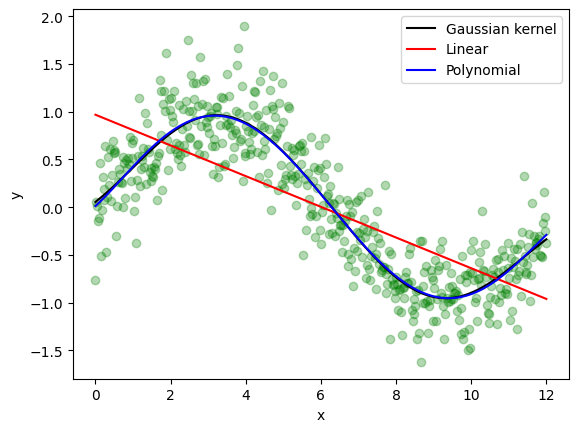

In [134]:
plt.scatter(x, y, c='green', alpha=0.3);
plt.plot(x, y_pred, c='black', label='Gaussian kernel');
plt.plot(x, linear.predict(x.reshape(-1, 1)), c='red', label='Linear');
plt.plot(x, poly.predict(x.reshape(-1, 1)), c='blue', label='Polynomial');
plt.xlabel('x');
plt.ylabel('y');
plt.legend();

In [137]:
file = open('poly.pkl', 'rb')
poly2 = pickle.load(file)

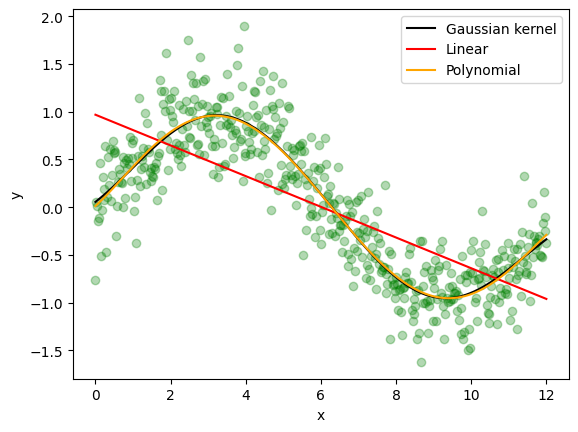

In [139]:
plt.scatter(x, y, c='green', alpha=0.3);
plt.plot(x, y_pred, c='black', label='Gaussian kernel');
plt.plot(x, linear.predict(x.reshape(-1, 1)), c='red', label='Linear');
plt.plot(x, poly2.predict(x.reshape(-1, 1)), c='orange', label='Polynomial');
plt.xlabel('x');
plt.ylabel('y');
plt.legend();

In [145]:
from sklearn.metrics import r2_score, mean_absolute_error

In [144]:
print(r2_score(y_true=y, y_pred=y_pred_kernel))
print(r2_score(y_true=y, y_pred=linear.predict(x.reshape(-1, 1))))
print(r2_score(y_true=y, y_pred=poly.predict(x.reshape(-1, 1))))

0.8353609692606357
0.5519499279791711
0.8351343835062676


In [147]:
print(mean_absolute_error(y_true=y, y_pred=y_pred_kernel))
print(mean_absolute_error(y_true=y, y_pred=linear.predict(x.reshape(-1, 1))))
print(mean_absolute_error(y_true=y, y_pred=poly.predict(x.reshape(-1, 1))))

0.238186353631637
0.4093765328684401
0.23885400938716214
